# Data Download & Weekly RV

Calls `src/data.py` functions. No logic lives here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import config
from src.data import (
    download_prices, compute_log_returns, compute_weekly_rv,
    make_target, make_splits, download_volume, download_tbill_rates
)

## Price Download & Universe Construction

In [2]:
prices = download_prices()
print(f"\nShape: {prices.shape}  ({prices.shape[1]} stocks × {prices.shape[0]} trading days)")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")

Fetching S&P 500 constituent list from Wikipedia...
Candidate universe: 50 tickers
After coverage filter (≥ 95%): 50 tickers
Fetching sector assignments for 50 tickers...
Saved: prices.parquet (50 stocks × 2765 days), tickers.json, sector_history.json → C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\raw/

Shape: (2765, 50)  (50 stocks × 2765 trading days)
Date range: 2015-01-02 → 2025-12-30


In [3]:
# Verify: no all-NaN columns survived the coverage filter
all_nan_cols = prices.columns[prices.isna().all()].tolist()
assert len(all_nan_cols) == 0, f"All-NaN columns found: {all_nan_cols}"
print(f"No All-NaN columns")

# Coverage stats
coverage = prices.notna().mean()
print(f"\nCoverage (non-NaN fraction):")
print(f"  Min : {coverage.min():.3f}  ({coverage.idxmin()})")
print(f"  Mean: {coverage.mean():.3f}")
print(f"  Max : {coverage.max():.3f}")

No All-NaN columns

Coverage (non-NaN fraction):
  Min : 1.000  (A)
  Mean: 1.000
  Max : 1.000


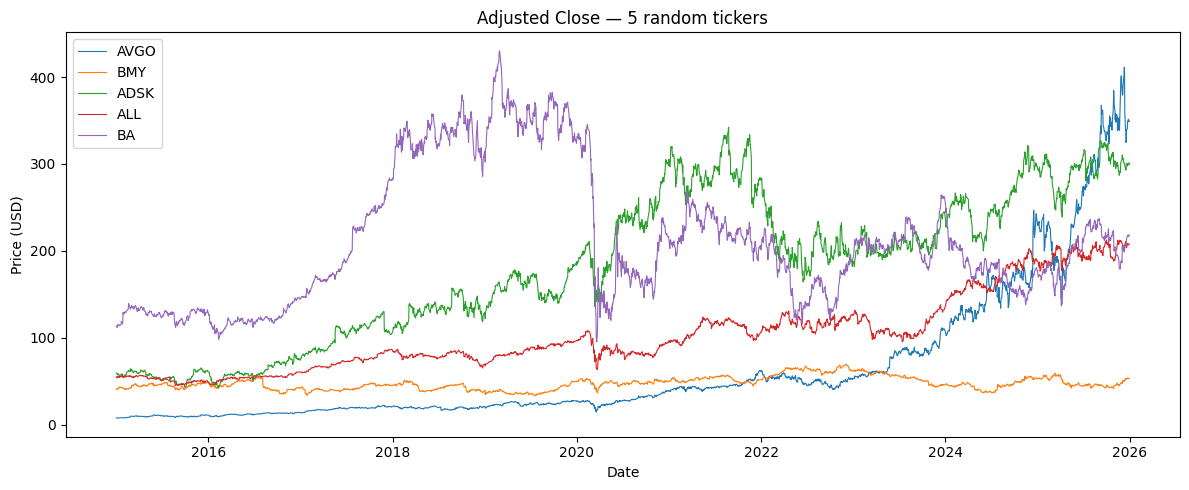

In [4]:
import matplotlib.pyplot as plt
import json, pathlib

# Plot 5 random stock price series
import numpy as np
rng = np.random.default_rng(config.RANDOM_SEED)
sample_tickers = rng.choice(prices.columns.tolist(), size=5, replace=False).tolist()

fig, ax = plt.subplots(figsize=(12, 5))
for t in sample_tickers:
    ax.plot(prices.index, prices[t], label=t, linewidth=0.8)
ax.set_title("Adjusted Close — 5 random tickers")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Spot-check sector_history.json
raw_dir = pathlib.Path("..") / config.DATA_RAW_DIR
with open(raw_dir / "sector_history.json") as f:
    sector_history = json.load(f)

example_ticker = sample_tickers[0]
if example_ticker in sector_history:
    print(f"{example_ticker} sector by year:")
    for yr, sec in sector_history[example_ticker].items():
        print(f"  {yr}: {sec}")
else:
    print("Not in universe")

AVGO sector by year:
  2015: Technology
  2016: Technology
  2017: Technology
  2018: Technology
  2019: Technology
  2020: Technology
  2021: Technology
  2022: Technology
  2023: Technology
  2024: Technology
  2025: Technology


## Volume Download

In [6]:
volume = download_volume()
print(f"Shape: {volume.shape}  ({volume.shape[1]} stocks × {volume.shape[0]} days)")
print(f"Date range: {volume.index[0].date()} → {volume.index[-1].date()}")

Saved: volume.parquet (50 stocks × 2765 days) → C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\raw/
Shape: (2765, 50)  (50 stocks × 2765 days)
Date range: 2015-01-02 → 2025-12-30


## Log Returns

In [7]:
import pathlib
log_returns = compute_log_returns(prices)
print(f"Shape: {log_returns.shape}  ({log_returns.shape[1]} stocks × {log_returns.shape[0]} days)")
print(f"Date range: {log_returns.index[0].date()} → {log_returns.index[-1].date()}")

Saved: log_returns.parquet (50 stocks × 2764 days) → C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\raw/
Shape: (2764, 50)  (50 stocks × 2764 days)
Date range: 2015-01-05 → 2025-12-30


In [8]:
# Mean and std per stock — mean should be ~0, std ~0.01–0.02
means = log_returns.mean()
stds  = log_returns.std()
print("Cross-stock mean of per-stock means:", f"{means.mean():.6f}  (expected ≈ 0)")
print("Cross-stock mean of per-stock stds: ", f"{stds.mean():.5f}  (expected 0.01–0.02)")
print(f"Std range: [{stds.min():.4f}, {stds.max():.4f}]")

Cross-stock mean of per-stock means: 0.000417  (expected ≈ 0)
Cross-stock mean of per-stock stds:  0.01855  (expected 0.01–0.02)
Std range: [0.0122, 0.0377]


In [9]:
# March 2020 spike check — week of 2020-03-16 should show returns of ±0.10+
covid_week = log_returns.loc["2020-03-16":"2020-03-20"]
print(f"Rows in COVID week: {len(covid_week)}")
print(f"Max absolute return that week: {covid_week.abs().max().max():.4f}  (expected ≥ 0.10)")
print(f"Cross-stock mean abs return:   {covid_week.abs().mean().mean():.4f}")
assert covid_week.abs().max().max() >= 0.10, "COVID week returns unexpectedly small — check price data"
print("COVID spike assertion passed.")

Rows in COVID week: 5
Max absolute return that week: 0.3907  (expected ≥ 0.10)
Cross-stock mean abs return:   0.0798
COVID spike assertion passed.


## Weekly Realized Volatility

In [10]:
weekly_rv = compute_weekly_rv(log_returns)

Saved: weekly_rv.parquet (50 stocks × 573 weeks) → C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\raw/


In [11]:
# Mean RV across all stocks and weeks — expected 0.15–0.25 annualized
mean_rv = weekly_rv.mean().mean()
print(f"Shape: {weekly_rv.shape}  ({weekly_rv.shape[1]} stocks x {weekly_rv.shape[0]} weeks)")
print(f"Date range: {weekly_rv.index[0].date()} -> {weekly_rv.index[-1].date()}")
print(f"Mean annualized RV: {mean_rv:.4f}  (expected 0.15-0.25)")
print(f"Min RV: {weekly_rv.min().min():.4f}   Max RV: {weekly_rv.max().max():.4f}")

Shape: (573, 50)  (50 stocks x 573 weeks)
Date range: 2015-01-05 -> 2025-12-22
Mean annualized RV: 0.2383  (expected 0.15-0.25)
Min RV: 0.0102   Max RV: 5.6861


In [12]:
# March 2020 spike — week starting 2020-03-16 should show RV of 0.80–1.50+
covid_week_idx = "2020-03-16"
if covid_week_idx in weekly_rv.index.astype(str).tolist():
    covid_rv = weekly_rv.loc[covid_week_idx]
else:
    # Find the week whose Monday is closest to 2020-03-16
    idx = weekly_rv.index.get_indexer([pd.Timestamp("2020-03-16")], method="nearest")[0]
    covid_rv = weekly_rv.iloc[idx]
    print(f"Using nearest week: {weekly_rv.index[idx].date()}")

import numpy as np
print(f"COVID week mean RV:   {covid_rv.mean():.4f}  (expected 0.80-1.50+)")
print(f"COVID week max RV:    {covid_rv.max():.4f}")
print(f"COVID week min RV:    {covid_rv.min():.4f}")
assert covid_rv.mean() >= 0.60, f"COVID week RV unexpectedly low: {covid_rv.mean():.4f}"
print("COVID week RV assertion passed.")

COVID week mean RV:   1.5021  (expected 0.80-1.50+)
COVID week max RV:    3.7474
COVID week min RV:    0.2494
COVID week RV assertion passed.


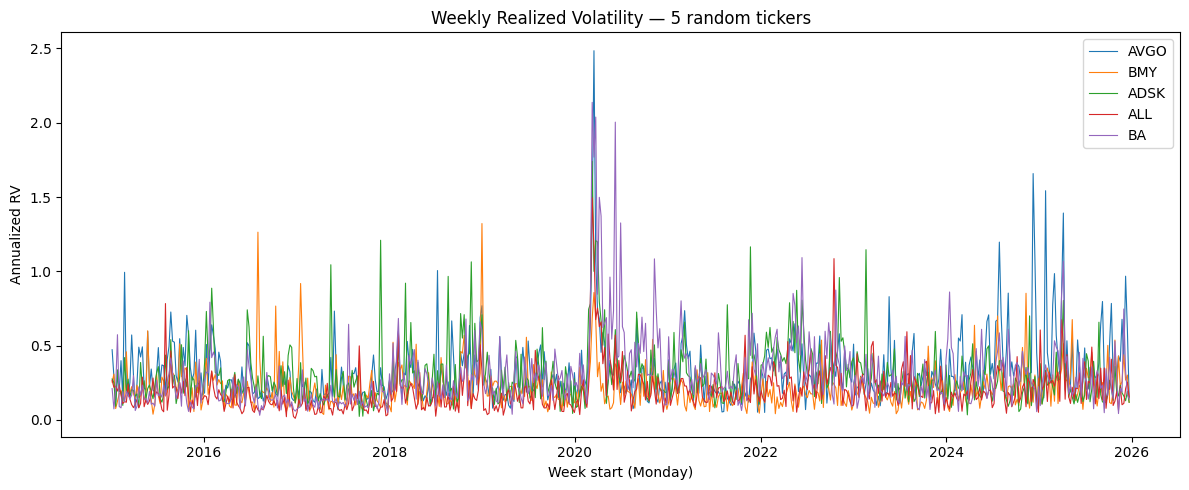

In [13]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(config.RANDOM_SEED)
sample_tickers = rng.choice(weekly_rv.columns.tolist(), size=5, replace=False).tolist()

fig, ax = plt.subplots(figsize=(12, 5))
for t in sample_tickers:
    ax.plot(weekly_rv.index, weekly_rv[t], label=t, linewidth=0.8)
ax.set_title("Weekly Realized Volatility — 5 random tickers")
ax.set_xlabel("Week start (Monday)")
ax.set_ylabel("Annualized RV")
ax.legend()
plt.tight_layout()
plt.show()

## Target Construction & Lookahead Audit

`target[T]` = RV from week T+1. The last row of `weekly_rv` is dropped (no T+1 exists).
Features at week T may only use data before week T starts — the shift direction is correct.

In [14]:
target = make_target(weekly_rv)
print(f"Shape: {target.shape}  ({target.shape[1]} stocks × {target.shape[0]} weeks)")
print(f"Index range: {target.index[0].date()} → {target.index[-1].date()}")
print(f"weekly_rv last row dropped: {weekly_rv.index[-1].date()} not in target: {weekly_rv.index[-1] not in target.index}")

Saved: target.parquet (50 stocks × 572 weeks) → C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\features/
Shape: (572, 50)  (50 stocks × 572 weeks)
Index range: 2015-01-05 → 2025-12-15
weekly_rv last row dropped: 2025-12-22 not in target: True


In [15]:
# Lookahead audit: for 5 rows, confirm target[T] == weekly_rv[T+1]
import numpy as np

rng = np.random.default_rng(config.RANDOM_SEED)
audit_positions = sorted(rng.choice(len(target), size=5, replace=False).tolist())
audit_ticker = target.columns[0]

print(f"Auditing column: {audit_ticker}")
print(f"{'Row T':>6}  {'Week T (features end before)':>30}  {'Week T+1 (target RV from)':>30}  {'target[T]':>12}  {'rv[T+1]':>12}  {'Match':>6}")
print("-" * 100)

all_match = True
for pos in audit_positions:
    week_t   = target.index[pos]       # Monday of week T
    week_t1  = weekly_rv.index[pos + 1]  # Monday of week T+1
    target_val = target.iloc[pos][audit_ticker]
    rv_t1_val  = weekly_rv.iloc[pos + 1][audit_ticker]
    match = np.isclose(target_val, rv_t1_val)
    all_match = all_match and match
    print(f"{pos:>6}  {str(week_t.date()):>30}  {str(week_t1.date()):>30}  {target_val:>12.6f}  {rv_t1_val:>12.6f}  {'YES' if match else '*** NO ***':>6}")

assert all_match, "Audit failed: target values do not match weekly_rv[T+1]"
print("\nLookahead audit passed: target[T] == weekly_rv[T+1] for all 5 sampled rows.")

Auditing column: A
 Row T    Week T (features end before)       Week T+1 (target RV from)     target[T]       rv[T+1]   Match
----------------------------------------------------------------------------------------------------
   113                      2017-03-06                      2017-03-13      0.320426      0.320426     YES
   208                      2018-12-31                      2019-01-07      0.102359      0.102359     YES
   376                      2022-03-21                      2022-03-28      0.319160      0.319160     YES
   438                      2023-05-29                      2023-06-05      0.156418      0.156418     YES
   540                      2025-05-12                      2025-05-19      0.298490      0.298490     YES

Lookahead audit passed: target[T] == weekly_rv[T+1] for all 5 sampled rows.


## Train / Val / Test Split

Boundaries: train ≤ 2022-12-31 · val ≤ 2023-12-31 · test > 2023-12-31.
Index is the target DataFrame's index (469 weeks after dropping last weekly_rv row).

In [16]:
splits = make_splits(target.index)

counts = splits["split"].value_counts()
print(f"Train weeks : {counts.get('train', 0):>4}  (expected ~400)")
print(f"Val weeks   : {counts.get('val',   0):>4}  (expected ~52)")
print(f"Test weeks  : {counts.get('test',  0):>4}  (expected ~104)")
print(f"Total       : {len(splits):>4}")

# Confirm no week is unassigned
assert set(splits["split"].unique()) == {"train", "val", "test"}, "Missing or unexpected split label"

# Spot-check boundaries
train_rows = splits[splits["split"] == "train"]
val_rows   = splits[splits["split"] == "val"]
test_rows  = splits[splits["split"] == "test"]

print(f"\nTrain: {train_rows['week'].min().date()} → {train_rows['week'].max().date()}")
print(f"Val  : {val_rows['week'].min().date()}   → {val_rows['week'].max().date()}")
print(f"Test : {test_rows['week'].min().date()}   → {test_rows['week'].max().date()}")

Split counts — train: 417, val: 52, test: 103
Saved: splits.parquet → C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\features/
Train weeks :  417  (expected ~400)
Val weeks   :   52  (expected ~52)
Test weeks  :  103  (expected ~104)
Total       :  572

Train: 2015-01-05 → 2022-12-26
Val  : 2023-01-02   → 2023-12-25
Test : 2024-01-01   → 2025-12-15
